# Audio Quality Classification - Explore Features Data
Goal: Explore data on features extracted from audio files 

Groups:

0. Single child voice. Files gathered from many different open-source/creative commons 0 data sources of kids reading / speaking sponteneously and checked for loud background noise or banging sounds to ensure there were none.
1. Child voice + banging sounds. 48 files from group 0 were artificially combined with 10 different banging/mic bump audio from (FreeSound.org)[FreeSound.org] with creative commons 0 license for commercial use. The remaining files were gathered from open-source sources that did have loud banging sounds because they were recorded in a noisy classroom, and also have multiple voices in the background.

Time-Domain Predictors: 
 - rms_avg: Root-mean-square energy (RMS) gives an estimate of loudness, and is less sensitive to outliers than amplitude envelope
 - rms_max: Gives a sense of the loudest sound in the recording
 - zcr_avg: Zero-crossing rate (ZCR) measures the number of times an audio signal crosses the horizontal axis. The horizontal axis represents an amplitude of 0. Speech tends to have a higher ZCR than music, singing, or periods of silence, so ZCR can be a rough way to detect different types of sound. 

Frequency-Domain Predictors: 
 - mfcc1-3_avg: lower-order Mel-Frequency Cepstral Coefficients give the general shape of the spectral envelope, capturing broad low-frequency spectral trends like overall energy distribution, loudness, timbre
 - mfcc4-9_avg: middle-order Mel-Frequency Cepstral Coefficients give finer details about spectral shape like locations and relationships of formants in the spectrum that distinguish between different sounds based on how the vocal tract was shaped
 - sc_avg: Spectral centroid gives a kind of average of the frequencies
 - sban_avg: Spectral bandwidth/spread gives an impression of how energy is spread across the frequency bands like a variance

Data source:

Feature extraction was run on all 140 files using analysis/feature_extraction.py and extract_features_on_many_files.py to create data/output.csv

Steps:

 - Check distribution of predictors, and transform them if there's skew
 - Check for statistically significant relationships between predictors and outcome. Drop predictor that lack a relationship
 - Check for multicollinearity where predictors are highly correlated with each other (too-similar predictors can be merged or dropped)
 - Split into x/y/train/test

Date last updated: 14May26

Author: Kay Rubio

In [ ]:
#!pip install jinja2

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
import sys
from pathlib import Path
from scipy.stats import mannwhitneyu
from sklearn.preprocessing import PowerTransformer
#from tabulate import tabulate

In [ ]:
# have to modify where notebook looks for imports so it looks in the project root, not the notebook folder
os.getcwd()
sys.path.append(str(Path().resolve().parent.parent))
print(sys.path)

['/Users/KRubio/.pyenv/versions/3.12.7/lib/python312.zip', '/Users/KRubio/.pyenv/versions/3.12.7/lib/python3.12', '/Users/KRubio/.pyenv/versions/3.12.7/lib/python3.12/lib-dynload', '', '/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification/.venv/lib/python3.12/site-packages', '/Users/KRubio/CA_Repos/kays_repos/audio_quality_classification']


In [46]:
# Import data
df = pd.read_csv("../data/output/output_clean.csv")

In [47]:
# Check data
df.head()

,filename,group,rms_avg,rms_min,rms_max,zcr_avg,zcr_min,zcr_max,mfcc0_avg,mfcc0_min,...,delta_mfcc11_max,delta_mfcc12_avg,delta_mfcc12_min,delta_mfcc12_max,sc_avg,sc_min,sc_max,sban_avg,sban_min,sban_max
0,pedro.wav,0,0.038011,0.000000,0.218165,0.096187,0.000000,0.659180,-493.25052,-647.78770,...,9.125058,0.000000,-6.201725,7.339862,1319.172935,0.000000,5316.600859,1078.074722,0.000000,2605.108913
1,five.wav,0,0.059544,0.000408,0.252014,0.160281,0.027344,0.630859,-389.97253,-611.70710,...,3.619711,-0.031475,-3.563357,4.444862,2048.152161,564.095995,4719.740989,1808.511393,973.862309,2734.802478
2,evie.wav,0,0.081612,0.000000,0.260786,0.203199,0.000000,0.905273,-315.54666,-632.01810,...,4.852911,-0.006991,-4.660733,4.506957,2663.348770,0.000000,6830.120279,2279.383334,0.000000,3124.311934
3,phonzy.wav,0,0.058511,0.003877,0.362025,0.109047,0.010742,0.607422,-329.89770,-497.81656,...,4.422121,0.001184,-4.877297,4.492741,1605.940058,516.168864,4726.258569,1577.458989,701.100924,3062.338464
4,zam.wav,0,0.034591,0.000789,0.218091,0.139011,0.025391,0.674805,-419.71286,-583.93440,...,4.882945,-0.004002,-5.468289,5.084243,1879.446718,429.711710,5180.982979,1790.642423,602.881459,2853.784739


In [48]:
# Keep only certain columns that are most likely to be useful for this analysis
predictors = [
  'rms_avg',
  'rms_max',
  'zcr_avg',
  'mfcc1_avg',
  'mfcc2_avg',
  'mfcc3_avg',
  'mfcc4_avg',
  'mfcc5_avg',
  'mfcc6_avg',
  'mfcc7_avg',
  'mfcc8_avg',
  'mfcc9_avg',
  'sc_avg',
  'sban_avg'
]
df = df[[
  'filename',
  'group',
  *predictors,
]]
df.head()

,filename,group,rms_avg,rms_max,zcr_avg,mfcc1_avg,mfcc2_avg,mfcc3_avg,mfcc4_avg,mfcc5_avg,mfcc6_avg,mfcc7_avg,mfcc8_avg,mfcc9_avg,sc_avg,sban_avg
0,pedro.wav,0,0.038011,0.218165,0.096187,55.698963,3.102218,11.284665,-43.277910,-18.425516,-15.812923,-5.484858,-13.553457,-11.790717,1319.172935,1078.074722
1,five.wav,0,0.059544,0.252014,0.160281,44.092113,-6.237860,6.245391,-8.226534,0.516584,-10.107016,-11.940651,-6.531712,-5.363322,2048.152161,1808.511393
2,evie.wav,0,0.081612,0.260786,0.203199,48.415940,40.183685,15.692126,14.286861,-10.826235,0.809604,2.913080,6.959134,0.819185,2663.348770,2279.383334
3,phonzy.wav,0,0.058511,0.362025,0.109047,93.107796,-2.953435,32.826164,-8.578085,-3.026895,2.197797,0.927445,-5.735558,-4.368426,1605.940058,1577.458989
4,zam.wav,0,0.034591,0.218091,0.139011,76.713190,8.343391,16.768433,-11.941475,6.421712,-6.289371,-0.051783,-10.975623,-1.792599,1879.446718,1790.642423


In [49]:
df.shape

(140, 16)

## Checking normality via histograms

In [50]:
def histogram(var):
    df[var].hist(bins=10, figsize=(6, 4))
    plt.title(var)
    plt.show()

count    140.000000
mean       0.077903
std        0.088433
min        0.005626
25%        0.023476
50%        0.044720
75%        0.111035
max        0.585452
Name: rms_avg, dtype: float64


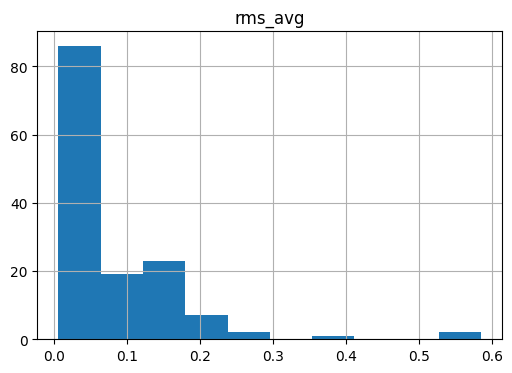


count    140.000000
mean       0.292855
std        0.238792
min        0.039053
25%        0.135203
50%        0.218128
75%        0.332394
max        0.967578
Name: rms_max, dtype: float64


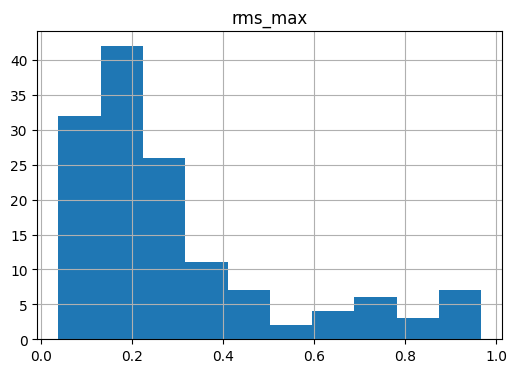


count    140.000000
mean       0.133243
std        0.084773
min        0.000000
25%        0.073210
50%        0.139419
75%        0.182677
max        0.342231
Name: zcr_avg, dtype: float64


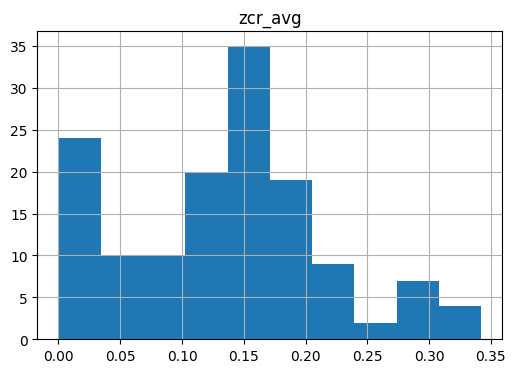


count    140.000000
mean      64.810073
std       24.930670
min        5.130007
25%       45.756187
50%       68.828980
75%       80.537010
max      145.823970
Name: mfcc1_avg, dtype: float64


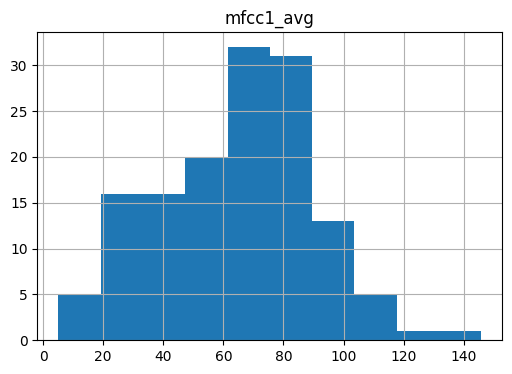


count    140.000000
mean       4.322807
std       20.521084
min      -53.442920
25%       -6.422083
50%        4.331935
75%       14.577754
max       62.085205
Name: mfcc2_avg, dtype: float64


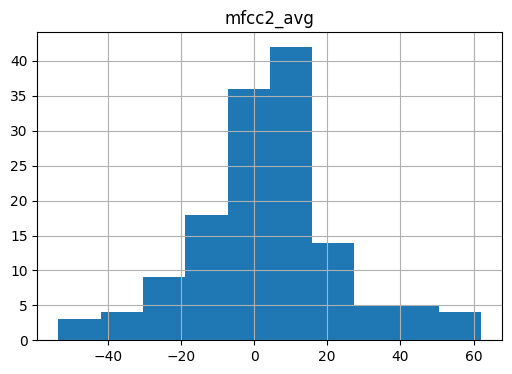


count    140.000000
mean      19.384485
std       13.016475
min      -17.441038
25%        8.641294
50%       19.406876
75%       28.144658
max       68.193950
Name: mfcc3_avg, dtype: float64


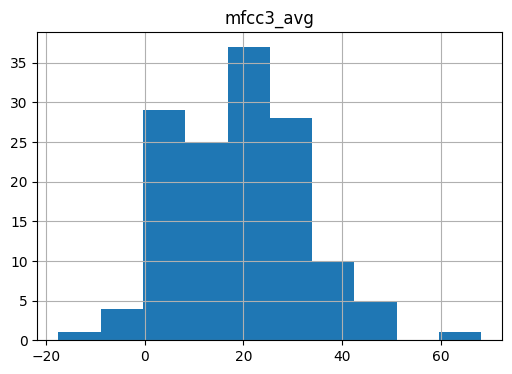


count    140.000000
mean      -8.115397
std       16.475640
min      -47.813570
25%      -16.677999
50%       -6.145998
75%        0.901232
max       33.476524
Name: mfcc4_avg, dtype: float64


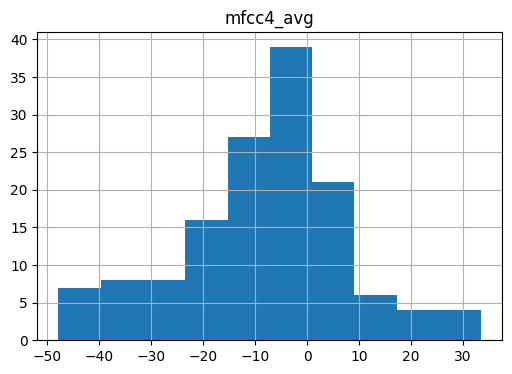


count    140.000000
mean       4.022089
std       10.510227
min      -22.393587
25%       -3.185053
50%        3.202810
75%       10.217980
max       29.008440
Name: mfcc5_avg, dtype: float64


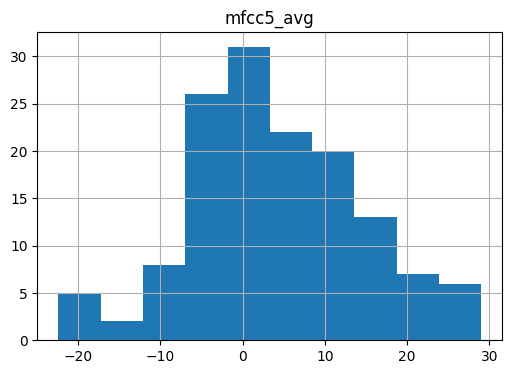


count    140.000000
mean      -4.165078
std       10.403291
min      -28.769196
25%      -10.111636
50%       -2.792585
75%        1.175082
max       21.788097
Name: mfcc6_avg, dtype: float64


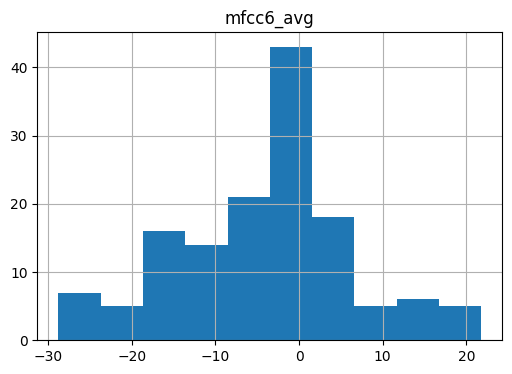


count    140.000000
mean       1.479089
std        8.436453
min      -20.441090
25%       -4.051376
50%        0.379213
75%        6.890350
max       20.842396
Name: mfcc7_avg, dtype: float64


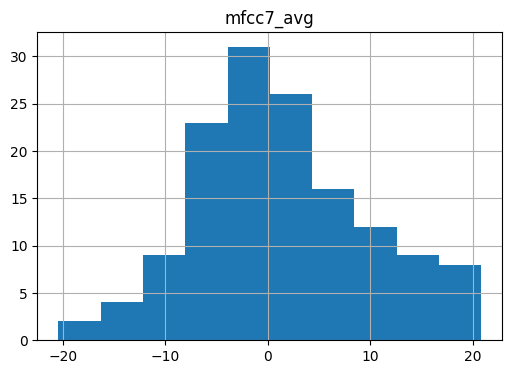


count    140.000000
mean      -0.565362
std        8.275277
min      -17.940594
25%       -4.555191
50%       -1.033156
75%        3.345388
max       23.953209
Name: mfcc8_avg, dtype: float64


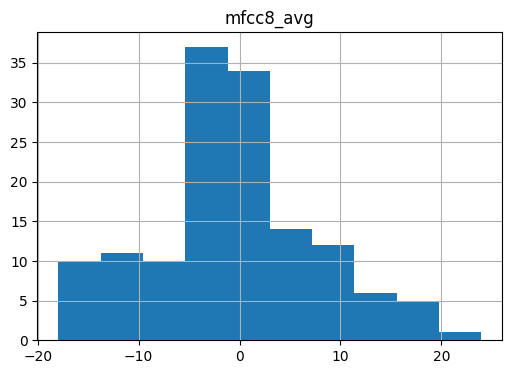


count    140.000000
mean       0.407091
std        7.936319
min      -21.193914
25%       -3.493379
50%       -0.422692
75%        5.833070
max       18.214790
Name: mfcc9_avg, dtype: float64


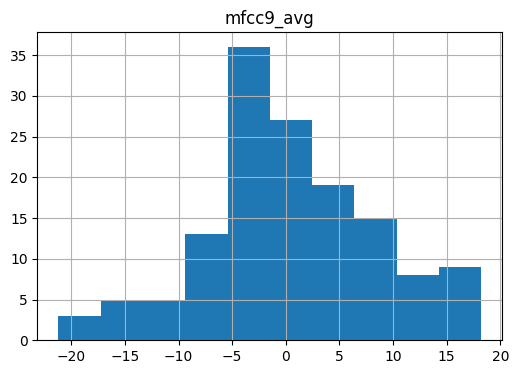


count     140.000000
mean     1754.847894
std       790.451731
min       167.984361
25%      1246.827521
50%      1924.780939
75%      2293.668409
max      3421.577751
Name: sc_avg, dtype: float64


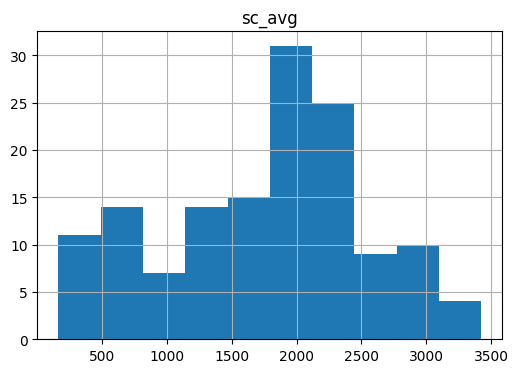


count     140.000000
mean     1641.281657
std       394.685304
min       696.510716
25%      1371.784168
50%      1726.472444
75%      1969.468881
max      2279.383334
Name: sban_avg, dtype: float64


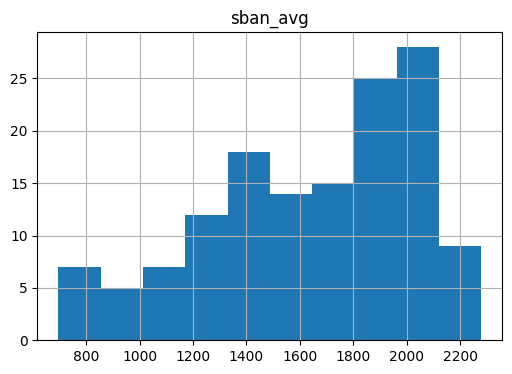

In [51]:
for col in predictors:
    print(df[col].describe()) # check min, max, mean, quartiles, std
    histogram(col) # turning off to avoid uploading too many images to github
    print()

From the above, zcr and the frequency-domain features look close enough to normally distributed to be reasonably used in logistic regression, but the rms energy average and are very far from normally distributed.

## Check multicollinearity
Hopefully each predictor is statistically different between the 2 groups, and also not too correlelated with any other predictor

In [52]:
# independent 2-sample t-tests between continuous predictors and outcome
for col in predictors:
    print(col)
    # Separate the data into two groups based on the binary outcome
    group0 = df[df['group'] == 0][col].to_numpy()
    group1 = df[df['group'] == 1][col].to_numpy()
    # Perform independent two-sample t-test
    t_stat, p_value = ttest_ind(group1, group0)
    # Display the results
    flag = " ***" if p_value < 0.05 else ""
    print(f't-statistic: {round(t_stat, 3)},  p-value: {round(p_value, 3)}{flag}')

rms_avg
t-statistic: 3.119,  p-value: 0.002 ***
rms_max
t-statistic: 5.704,  p-value: 0.0 ***
zcr_avg
t-statistic: -3.527,  p-value: 0.001 ***
mfcc1_avg
t-statistic: 3.008,  p-value: 0.003 ***
mfcc2_avg
t-statistic: 5.397,  p-value: 0.0 ***
mfcc3_avg
t-statistic: 2.576,  p-value: 0.011 ***
mfcc4_avg
t-statistic: 5.62,  p-value: 0.0 ***
mfcc5_avg
t-statistic: 3.683,  p-value: 0.0 ***
mfcc6_avg
t-statistic: 6.697,  p-value: 0.0 ***
mfcc7_avg
t-statistic: 3.353,  p-value: 0.001 ***
mfcc8_avg
t-statistic: 4.927,  p-value: 0.0 ***
mfcc9_avg
t-statistic: 4.583,  p-value: 0.0 ***
sc_avg
t-statistic: -2.471,  p-value: 0.015 ***
sban_avg
t-statistic: 0.786,  p-value: 0.433


From the above, everything is related to the outcome except for spectral bandwidth which has no relationship, and the results for root mean square energy could be biased since these are not normally distributed, so will check with a non-parametric test, Mann-Whitney U Test

In [53]:
right_skewed_predictors = ['rms_avg', 'rms_max']
for col in right_skewed_predictors:
    print(col)
    group0 = df[df['group'] == 0][col].to_numpy()
    group1 = df[df['group'] == 1][col].to_numpy()
    stat, p_value = mannwhitneyu(group1, group0, alternative='two-sided')
    flag = " ***" if p_value < 0.05 else ""
    print(f'U-statistic: {round(stat, 3)}  p-value: {round(p_value, 3)}{flag}')

rms_avg
U-statistic: 3470.0  p-value: 0.0 ***
rms_max
U-statistic: 3892.0  p-value: 0.0 ***


Looks like despite the poor distribution root mean square energy can still add to the model. 

## Transform skewed variables

count    140.000000
mean       0.072089
std        0.074459
min        0.005610
25%        0.023205
50%        0.043749
75%        0.105227
max        0.460870
Name: rms_avg_log, dtype: float64


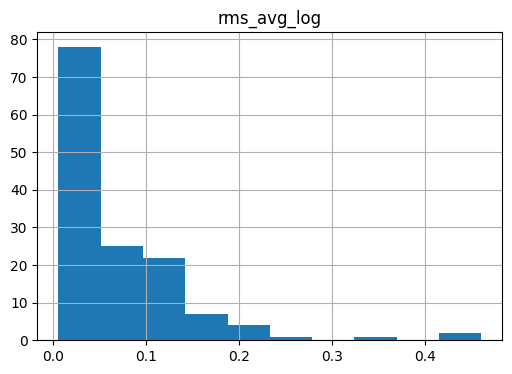


count    140.000000
mean       0.241973
std        0.167808
min        0.038310
25%        0.126812
50%        0.197315
75%        0.286977
max        0.676804
Name: rms_max_log, dtype: float64


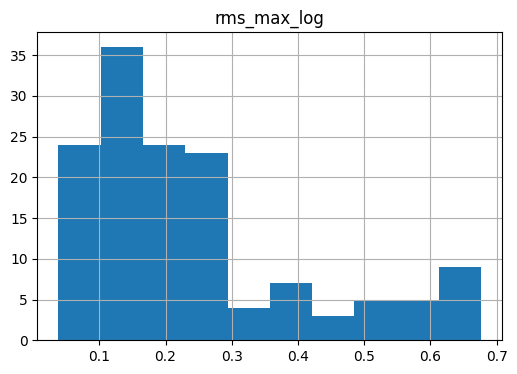

In [54]:
# Log transformation for long-tail to the right distributions (skewed right)
transformed_predictors = []
for col in right_skewed_predictors:
  df[f'{col}_log'] = np.log1p(df[col])
  transformed_predictors.append(f'{col}_log')
  # Log transformation for long-tail to the left distributions (skewed left)
  # df[f'{col}_log'] = np.log1p(df[f'{col}'].max() - df[f'{col}'])

for col in transformed_predictors:
    print(df[col].describe()) # check min, max, mean, quartiles, std
    histogram(col) # turning off to avoid uploading too many images to github
    print()

count    1.400000e+02
mean     2.537653e-17
std      1.003591e+00
min     -1.480392e+00
25%     -8.416942e-01
50%     -2.378627e-01
75%      9.194210e-01
max      2.098009e+00
Name: rms_avg_yj, dtype: float64


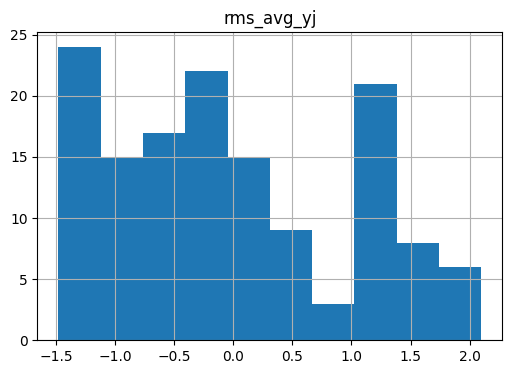


count    1.400000e+02
mean     2.537653e-16
std      1.003591e+00
min     -1.815124e+00
25%     -7.042129e-01
50%     -4.003467e-02
75%      5.945696e-01
max      1.853229e+00
Name: rms_max_yj, dtype: float64


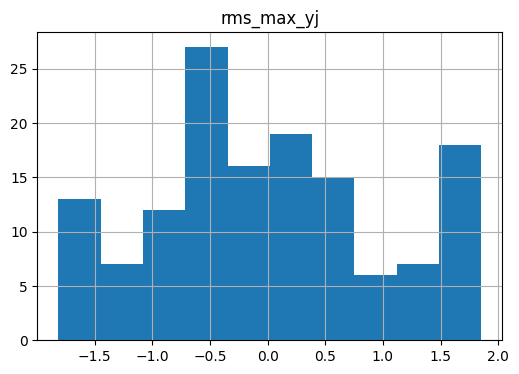

In [55]:
# Those still look pretty bad, so try the Yeo-Johnson power transformation
pt = PowerTransformer(method='yeo-johnson')
yeo_johnson_transformed_predictors = []
for col in right_skewed_predictors:
  df[f'{col}_yj'] = pt.fit_transform(df[[col]])
  yeo_johnson_transformed_predictors.append(f'{col}_yj')
  # Log transformation for long-tail to the left distributions (skewed left)
  # df[f'{col}_log'] = np.log1p(df[f'{col}'].max() - df[f'{col}'])

for col in yeo_johnson_transformed_predictors:
    print(df[col].describe()) # check min, max, mean, quartiles, std
    histogram(col) # turning off to avoid uploading too many images to github
    print()


In [56]:
# Those look better, so lets just make sure they're still correlated with the outcome
for col in yeo_johnson_transformed_predictors:
    print(col)
    group0 = df[df['group'] == 0][col].to_numpy()
    group1 = df[df['group'] == 1][col].to_numpy()
    stat, p_value = mannwhitneyu(group1, group0, alternative='two-sided')
    flag = " ***" if p_value < 0.05 else ""
    print(f'U-statistic: {round(stat, 3)}  p-value: {round(p_value, 3)}{flag}')

rms_avg_yj
U-statistic: 3470.0  p-value: 0.0 ***
rms_max_yj
U-statistic: 3892.0  p-value: 0.0 ***


In [57]:
df.head()

,filename,group,rms_avg,rms_max,zcr_avg,mfcc1_avg,mfcc2_avg,mfcc3_avg,mfcc4_avg,mfcc5_avg,mfcc6_avg,mfcc7_avg,mfcc8_avg,mfcc9_avg,sc_avg,sban_avg,rms_avg_log,rms_max_log,rms_avg_yj,rms_max_yj
0,pedro.wav,0,0.038011,0.218165,0.096187,55.698963,3.102218,11.284665,-43.277910,-18.425516,-15.812923,-5.484858,-13.553457,-11.790717,1319.172935,1078.074722,0.037307,0.197345,-0.412578,-0.039785
1,five.wav,0,0.059544,0.252014,0.160281,44.092113,-6.237860,6.245391,-8.226534,0.516584,-10.107016,-11.940651,-6.531712,-5.363322,2048.152161,1808.511393,0.057838,0.224754,0.103572,0.176278
2,evie.wav,0,0.081612,0.260786,0.203199,48.415940,40.183685,15.692126,14.286861,-10.826235,0.809604,2.913080,6.959134,0.819185,2663.348770,2279.383334,0.078453,0.231736,0.516047,0.228000
3,phonzy.wav,0,0.058511,0.362025,0.109047,93.107796,-2.953435,32.826164,-8.578085,-3.026895,2.197797,0.927445,-5.735558,-4.368426,1605.940058,1577.458989,0.056864,0.308972,0.081633,0.721456
4,zam.wav,0,0.034591,0.218091,0.139011,76.713190,8.343391,16.768433,-11.941475,6.421712,-6.289371,-0.051783,-10.975623,-1.792599,1879.446718,1790.642423,0.034007,0.197285,-0.507073,-0.040285


## Multicollinearity between predictors

In [58]:
# make dataset with only continous predictors
df_predictors_only = df.drop(['filename', 'group'], axis=1)

# Calculate the correlation matrix
correlation_matrix = df_predictors_only.corr()

# Create a styled correlation table with color highlighting
styled_corr_table = correlation_matrix.style.background_gradient(cmap='coolwarm')

# Display the styled correlation table
styled_corr_table

,rms_avg,rms_max,zcr_avg,mfcc1_avg,mfcc2_avg,mfcc3_avg,mfcc4_avg,mfcc5_avg,mfcc6_avg,mfcc7_avg,mfcc8_avg,mfcc9_avg,sc_avg,sban_avg,rms_avg_log,rms_max_log,rms_avg_yj,rms_max_yj
rms_avg,1.000000,0.715843,-0.599916,0.226382,0.477515,0.345071,0.456843,0.459051,0.453396,0.503833,0.528633,0.483961,-0.621775,-0.531116,0.996830,0.700528,0.840555,0.624647
rms_max,0.715843,1.000000,-0.456190,0.323559,0.524193,0.321276,0.402439,0.359192,0.465359,0.461364,0.556871,0.404619,-0.472234,-0.378669,0.729407,0.996430,0.715474,0.928867
zcr_avg,-0.599916,-0.456190,1.000000,-0.564088,-0.402786,-0.528017,-0.441065,-0.557320,-0.508551,-0.531599,-0.609833,-0.465722,0.956692,0.740830,-0.631493,-0.464460,-0.742948,-0.478499
mfcc1_avg,0.226382,0.323559,-0.564088,1.000000,0.098083,0.271061,0.161392,0.137879,0.172364,0.039564,0.318193,-0.010433,-0.576673,-0.449112,0.240691,0.350291,0.349553,0.425419
mfcc2_avg,0.477515,0.524193,-0.402786,0.098083,1.000000,0.322716,0.742442,0.477263,0.756012,0.574721,0.660776,0.673193,-0.359126,-0.068686,0.480191,0.516790,0.417228,0.467983
mfcc3_avg,0.345071,0.321276,-0.528017,0.271061,0.322716,1.000000,0.252501,0.605142,0.413322,0.558933,0.470721,0.417484,-0.534294,-0.511948,0.352776,0.313122,0.344375,0.263898
mfcc4_avg,0.456843,0.402439,-0.441065,0.161392,0.742442,0.252501,1.000000,0.488145,0.842152,0.491219,0.689559,0.657994,-0.406230,-0.094755,0.459841,0.395167,0.400420,0.352907
mfcc5_avg,0.459051,0.359192,-0.557320,0.137879,0.477263,0.605142,0.488145,1.000000,0.557780,0.686860,0.642536,0.650971,-0.570317,-0.440598,0.478259,0.351712,0.507875,0.303422
mfcc6_avg,0.453396,0.465359,-0.508551,0.172364,0.756012,0.413322,0.842152,0.557780,1.000000,0.586481,0.730372,0.774090,-0.452992,-0.183204,0.455740,0.451100,0.388674,0.382912
mfcc7_avg,0.503833,0.461364,-0.531599,0.039564,0.574721,0.558933,0.491219,0.686860,0.586481,1.000000,0.594446,0.686494,-0.538079,-0.442003,0.515064,0.444809,0.479860,0.363288


mfcc1 and mfcc9 are somewhat correlated ~.01, but everything else looks unrelated, so I think this is OK

## Final Dataset, split x/y/train/test

In [59]:
# make dataset with only continous predictors. Drop original rms cols, and spectral bandwidth which has no relationship to outcome
# yeo-johnson variables look better for rms energy, but can't do the same transform for inference, so keep the log ones
df_final = df.drop(['rms_avg', 'rms_max', 'rms_avg_yj', 'rms_max_yj', 'sban_avg'], axis=1)
df_final.head()

,filename,group,zcr_avg,mfcc1_avg,mfcc2_avg,mfcc3_avg,mfcc4_avg,mfcc5_avg,mfcc6_avg,mfcc7_avg,mfcc8_avg,mfcc9_avg,sc_avg,rms_avg_log,rms_max_log
0,pedro.wav,0,0.096187,55.698963,3.102218,11.284665,-43.277910,-18.425516,-15.812923,-5.484858,-13.553457,-11.790717,1319.172935,0.037307,0.197345
1,five.wav,0,0.160281,44.092113,-6.237860,6.245391,-8.226534,0.516584,-10.107016,-11.940651,-6.531712,-5.363322,2048.152161,0.057838,0.224754
2,evie.wav,0,0.203199,48.415940,40.183685,15.692126,14.286861,-10.826235,0.809604,2.913080,6.959134,0.819185,2663.348770,0.078453,0.231736
3,phonzy.wav,0,0.109047,93.107796,-2.953435,32.826164,-8.578085,-3.026895,2.197797,0.927445,-5.735558,-4.368426,1605.940058,0.056864,0.308972
4,zam.wav,0,0.139011,76.713190,8.343391,16.768433,-11.941475,6.421712,-6.289371,-0.051783,-10.975623,-1.792599,1879.446718,0.034007,0.197285


In [60]:
# Split into x, y
# split the df into x and y
y = df_final[['group']]
y.head() # check it

,group
0,0
1,0
2,0
3,0
4,0


In [61]:
x = df_final.drop(['group', 'filename'], axis=1) # x is the df with only predictor columns
x.head() # check it

,zcr_avg,mfcc1_avg,mfcc2_avg,mfcc3_avg,mfcc4_avg,mfcc5_avg,mfcc6_avg,mfcc7_avg,mfcc8_avg,mfcc9_avg,sc_avg,rms_avg_log,rms_max_log
0,0.096187,55.698963,3.102218,11.284665,-43.277910,-18.425516,-15.812923,-5.484858,-13.553457,-11.790717,1319.172935,0.037307,0.197345
1,0.160281,44.092113,-6.237860,6.245391,-8.226534,0.516584,-10.107016,-11.940651,-6.531712,-5.363322,2048.152161,0.057838,0.224754
2,0.203199,48.415940,40.183685,15.692126,14.286861,-10.826235,0.809604,2.913080,6.959134,0.819185,2663.348770,0.078453,0.231736
3,0.109047,93.107796,-2.953435,32.826164,-8.578085,-3.026895,2.197797,0.927445,-5.735558,-4.368426,1605.940058,0.056864,0.308972
4,0.139011,76.713190,8.343391,16.768433,-11.941475,6.421712,-6.289371,-0.051783,-10.975623,-1.792599,1879.446718,0.034007,0.197285


In [63]:
# Split into default 25% test and 75% training
# add a seed to the randomizer so the split will be consistent/reproducible
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 1234)

In [ ]:
# export datasets to be used in models
x_train.to_csv('../data/x_train.csv')
y_train.to_csv('../data/y_train.csv')
x_test.to_csv('../data/x_test.csv')
y_test.to_csv('../data/y_test.csv')

In [66]:
# Export the final dataset that includes filenames
df_final.to_csv('../data/df_final.csv')